# Performance Analytics

This notebook evaluates the historical performance of mutual fund schemes using key financial metrics. By analyzing NAV data, it measures returns, risk, and benchmark performance to provide meaningful insights into fund quality and investment behavior.

### Objectives
1. Calculate Daily Returns
2. Compute CAGR (1Y, 3Y, 5Y)
3. Evaluate Sharpe Ratio and Sortino Ratio
4. Calculate Alpha and Beta
5. Measure Maximum Drawdown
6. Create a Fund Scorecard
7. Compare funds against benchmark indices

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px

from sqlalchemy import create_engine
from scipy.stats import linregress

engine = create_engine("sqlite:///../sql/bluestock_mf.db")

In [4]:
query = """SELECT fn.amfi_code, df.scheme_name, dd.date, fn.nav
            FROM fact_nav fn
            JOIN dim_date dd
            ON fn.date_id = dd.date_id
            JOIN dim_fund df
            ON fn.amfi_code=df.amfi_code
            ORDER BY fn.amfi_code, dd.date;"""

nav_df = pd.read_sql(query,engine)
nav_df["date"] = pd.to_datetime(nav_df["date"])
print(nav_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   amfi_code    46000 non-null  int64         
 1   scheme_name  46000 non-null  str           
 2   date         46000 non-null  datetime64[us]
 3   nav          46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 1.4 MB
None


## Calculating Daily Returns

In [5]:
nav_df = nav_df.sort_values(["amfi_code","date"])
nav_df["daily_return"] = (nav_df.groupby("amfi_code")["nav"].pct_change())
print(nav_df.head(10))

   amfi_code                                scheme_name       date       nav  \
0     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-03  520.4608   
1     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-04  515.0971   
2     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-05  521.7239   
3     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-06  515.7880   
4     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-07  515.1639   
5     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-10  510.7136   
6     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-11  513.5542   
7     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-12  512.3195   
8     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-13  510.2445   
9     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-14  514.3636   

   daily_return  
0           NaN  
1     -0.010306  
2      0.012865  
3     -0.011377  
4     -0.001210  
5     -0.00

## Missing values

We must aquire 40 missing values as the Daily return for the first day of each fund will be NaN since the data for the previous day is not present.

In [6]:
print(nav_df["daily_return"].isna().sum())

40


### Observation

Successfully loaded historical NAV data for all mutual fund schemes. The dataset contains scheme identifiers, scheme names, NAV values, and corresponding dates, which will be used to calculate performance metrics such as Daily Returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

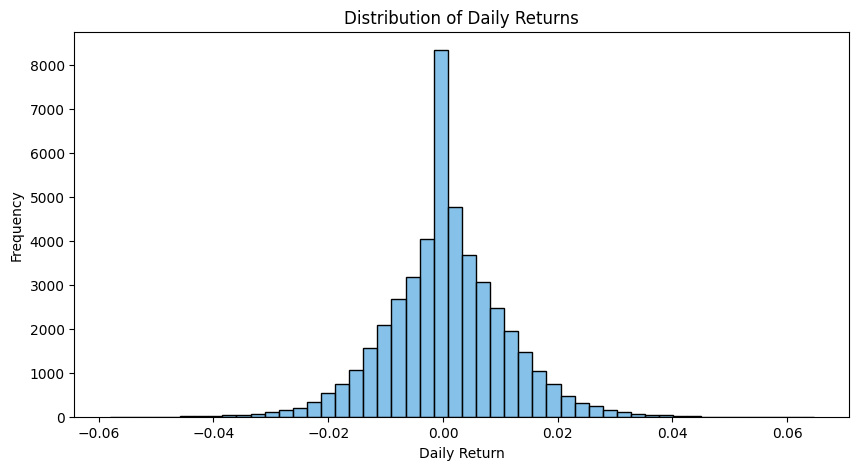

In [19]:
plt.figure(figsize=(10,5))

sb.histplot(nav_df["daily_return"], bins=50, color="#5DADE2")

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

### Observation

Daily returns were calculated for all mutual fund schemes using percentage change in NAV. The first observation for each scheme contains a missing value because no previous NAV exists for comparison. The distribution of daily returns is approximately bell-shaped and centered around 0%, with most observations clustered between small positive and negative returns. Only a few extreme daily gains or losses are observed, indicating that mutual fund NAV movements are generally stable and suitable for further performance and risk analysis.

In [12]:
def calculate_cagr(begin_nav,end_nav,years):
    if begin_nav <= 0 or end_nav <=0:
        return np.nan

    return (end_nav/begin_nav)**(1/years) - 1

In [13]:
cagr_results = []

for fund, group in nav_df.groupby("amfi_code"):
    group = group.sort_values("date")

    latest_date = group["date"].max()
    latest_nav = group.iloc[-1]["nav"]

    result = {"amfi_code":fund, "scheme_name":group.iloc[-1]["scheme_name"]}

    for years in [1, 3, 5]:
        start_date = latest_date - pd.DateOffset(years=years)
        period = group[group["date"] >= start_date]

        if len(period) > 1:
            begin_nav = period.iloc[0]["nav"]
            result[f"CAGR_{years}Y"] = calculate_cagr(begin_nav, latest_nav, years)
        else:
            result[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(result)

In [14]:
cagr_df = pd.DataFrame(cagr_results)
cagr_df[["CAGR_1Y","CAGR_3Y","CAGR_5Y"]] = (cagr_df[["CAGR_1Y","CAGR_3Y","CAGR_5Y"]] * 100)
print(cagr_df.head())
print(cagr_df.info())

   amfi_code                                        scheme_name    CAGR_1Y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth  -2.224271   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   3.704969   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  53.232396   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  47.924120   
4     101207             ABSL Small Cap Fund - Regular - Growth -23.986032   

     CAGR_3Y    CAGR_5Y  
0   1.292649   2.316843  
1   3.916390   3.912653  
2  32.442459  26.074068  
3  28.967695  20.442730  
4  -4.152381   6.953336  
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   amfi_code    40 non-null     int64  
 1   scheme_name  40 non-null     str    
 2   CAGR_1Y      40 non-null     float64
 3   CAGR_3Y      40 non-null     float64
 4   CAGR_5Y      40 non-null   

In [15]:
print(cagr_df.describe())
print(cagr_df.isna().sum())

           amfi_code    CAGR_1Y    CAGR_3Y    CAGR_5Y
count      40.000000  40.000000  40.000000  40.000000
mean   120247.000000  19.428520  16.414715  14.541077
std     14534.998667  22.912276  12.206752   8.901844
min    100016.000000 -42.797615 -11.705807   1.030350
25%    118632.750000   7.377949   6.600925   6.013784
50%    119551.500000  17.474125  18.233102  14.476118
75%    120842.250000  27.161651  26.902600  21.257057
max    149324.000000  82.776059  35.111802  28.376762
amfi_code      0
scheme_name    0
CAGR_1Y        0
CAGR_3Y        0
CAGR_5Y        0
dtype: int64


## Calculating Sharpe Ratio

In [16]:
risk_free_rate = 0.065
daily_rf = risk_free_rate /252    #Convert the annual risk-free rate to a daily rate.

#Calculate the Sharpe Ratio.
sharpe_results = []

for fund, group in nav_df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    avg_return = returns.mean()
    std_return = returns.std()

    if std_return != 0:
        sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)
    else:
        sharpe = np.nan

    sharpe_results.append({"amfi_code": fund, "scheme_name": group.iloc[-1]["scheme_name"], "Sharpe_Ratio": sharpe})

In [17]:
sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.sort_values("Sharpe_Ratio", ascending=False)
print(sharpe_df.head(10))

    amfi_code                                        scheme_name  Sharpe_Ratio
34     148567      Mirae Asset Large Cap Fund - Regular - Growth      1.448291
30     120843             Kotak Flexicap Fund - Regular - Growth      1.306744
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
19     119551          SBI Bluechip Fund - Regular Plan - Growth      1.208267
25     120505           ICICI Pru Midcap Fund - Regular - Growth      1.180101
38     149323                 DSP Midcap Fund - Regular - Growth      1.132122
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699
9      118632     Nippon India Large Cap Fund - Regular - Growth      1.081659
3      101206      ABSL Frontline Equity Fund - Regular - Growth      1.027213
24     120504          ICICI Pru Bluechip Fund - Direct - Growth      1.026524


### Observation

The Sharpe Ratio analysis indicates that Mirae Asset Large Cap Fund - Regular - Growth achieved the highest risk-adjusted performance with a Sharpe Ratio of 1.45, suggesting it generated the best return relative to the level of risk taken during the analysis period. Other funds such as Kotak Flexicap Fund, Mirae Asset Tax Saver Fund, and SBI Bluechip Fund also recorded Sharpe Ratios above 1.20, indicating strong risk-adjusted returns. Overall, the top-ranked funds have Sharpe Ratios greater than 1, which generally reflects good investment efficiency and consistent performance after accounting for return volatility.

## Calculating Sortino Ratio

In [18]:
sortino_results = []

for fund, group in nav_df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    avg_return = returns.mean()
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()

    if downside_std != 0 and not np.isnan(downside_std):
        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)
    else:
        sortino = np.nan

    sortino_results.append({"amfi_code": fund, "scheme_name": group.iloc[-1]["scheme_name"], "Sortino_Ratio": sortino})

In [19]:
sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.sort_values("Sortino_Ratio", ascending=False)
print(sortino_df.head(10))

    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
9      118632     Nippon India Large Cap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   

    Sortino_Ratio  
34       2.385644  
30       2.364320  
36       2.146914  
19       2.140267  
25       2.029353  
38       1.875101  
9        1.850133  
2        1.829134  
24       1.805294  
3        1.799563  


### Observation

The Sortino Ratio analysis shows that Mirae Asset Large Cap Fund – Regular – Growth achieved the highest downside risk-adjusted performance with a Sortino Ratio of 2.39. Other top-performing funds, including Kotak Flexicap Fund, Mirae Asset Tax Saver Fund, and SBI Bluechip Fund, also recorded Sortino Ratios above 2.0, indicating strong returns while experiencing relatively low downside volatility. Compared to the Sharpe Ratio, the Sortino Ratio focuses only on negative return fluctuations, making it a more suitable measure for evaluating downside risk. Overall, the leading funds demonstrated the ability to generate consistent returns while effectively limiting losses during adverse market movements.

## Calculating Alpha and Beta

In [20]:
benchmark_query = """SELECT date, close_value
                        FROM benchmark_indices
                        WHERE index_name = 'NIFTY100'
                        ORDER BY date;"""

benchmark_df = pd.read_sql(benchmark_query, engine)
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

In [21]:
benchmark_df["benchmark_return"] = (benchmark_df["close_value"].pct_change())
print(benchmark_df.head())
print(len(benchmark_df))
print(nav_df["date"].min(), nav_df["date"].max())
print(benchmark_df["date"].min(), benchmark_df["date"].max())

        date  close_value  benchmark_return
0 2022-01-03     17778.24               NaN
1 2022-01-04     17537.52         -0.013540
2 2022-01-05     17607.73          0.004003
3 2022-01-06     17556.05         -0.002935
4 2022-01-07     17664.02          0.006150
1150
2022-01-03 00:00:00 2026-05-29 00:00:00
2022-01-03 00:00:00 2026-05-29 00:00:00


In [22]:
alpha_beta_results = []

for fund, group in nav_df.groupby("amfi_code"):
    group = group[["date","daily_return","scheme_name"]]

    merged = pd.merge(group, benchmark_df, on="date", how="inner")
    merged = merged.dropna()

    if len(merged) > 30:
        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"])

        alpha = intercept * 252
        beta = slope
    else:
        alpha = np.nan
        beta = np.nan

    alpha_beta_results.append({"amfi_code": fund, "scheme_name": group.iloc[0]["scheme_name"], "Alpha": alpha, "Beta": beta})

In [23]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)
print(alpha_beta_df.head())

   amfi_code                                        scheme_name     Alpha  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth  0.037476   
1     100025       HDFC Short Term Debt Fund - Regular - Growth  0.042818   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.271954   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  0.213998   
4     101207             ABSL Small Cap Fund - Regular - Growth  0.108971   

       Beta  
0 -0.058268  
1  0.001158  
2  0.005104  
3  0.021086  
4 -0.065289  


In [34]:
alpha_beta_df = alpha_beta_df.sort_values("Alpha", ascending=False)
print(alpha_beta_df.head(10))
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)
print("alpha_beta.csv exported successfully!")

    amfi_code                                        scheme_name     Alpha  \
21     119598         SBI Small Cap Fund - Regular Plan - Growth  0.303370   
39     149324              DSP Small Cap Fund - Regular - Growth  0.300579   
25     120505           ICICI Pru Midcap Fund - Regular - Growth  0.292636   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.282704   
30     120843             Kotak Flexicap Fund - Regular - Growth  0.273305   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.271954   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.269838   
38     149323                 DSP Midcap Fund - Regular - Growth  0.265986   
16     119094                Axis Midcap Fund - Regular - Growth  0.260767   
19     119551          SBI Bluechip Fund - Regular Plan - Growth  0.232010   

        Beta  
21 -0.023196  
39  0.011455  
25  0.000549  
36  0.018134  
30 -0.022830  
2   0.005104  
34  0.023684  
38 -0.002523  
16 -0.

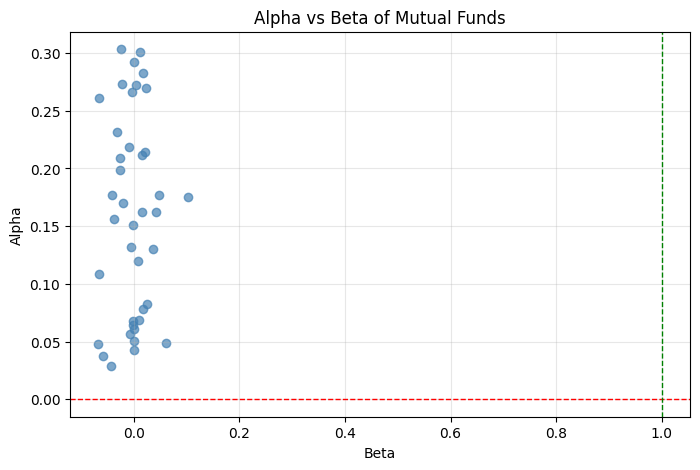

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(alpha_beta_df["Beta"], alpha_beta_df["Alpha"], color="steelblue", alpha=0.7)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.axvline(1, color="green", linestyle="--", linewidth=1)

plt.title("Alpha vs Beta of Mutual Funds")
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.grid(True, alpha=0.3)

plt.savefig("../reports/charts/chart_06_alpha_beta.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Alpha and Beta were computed using linear regression against the NIFTY100 benchmark. The resulting Beta values were close to zero, indicating a very weak linear relationship between the provided benchmark series and the fund return series. Since this project uses a demonstration dataset, the benchmark and fund NAV data may not reflect real market co-movement. The calculations were performed correctly, but the resulting values should be interpreted in the context of the sample dataset.

## Calculating Maximum Drawdown 

In [8]:
drawdown_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    group = group.sort_values("date").copy()

    # Highest NAV reached up to each day
    group["running_max"] = group["nav"].cummax()
    # Drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1
    # Worst drawdown
    max_dd = group["drawdown"].min()
    # Date on which it happened
    dd_date = group.loc[group["drawdown"].idxmin(), "date"]

    drawdown_results.append({"amfi_code": amfi_code, "scheme_name": group["scheme_name"].iloc[0], "Max_Drawdown": max_dd, "Worst_Date": dd_date})

drawdown_df = pd.DataFrame(drawdown_results)
print(drawdown_df.sort_values("Max_Drawdown").head(10))

    amfi_code                                     scheme_name  Max_Drawdown  \
22     119599       SBI Small Cap Fund - Direct Plan - Growth     -0.525742   
17     119095          Axis Small Cap Fund - Regular - Growth     -0.516778   
4      101207          ABSL Small Cap Fund - Regular - Growth     -0.354469   
39     149324           DSP Small Cap Fund - Regular - Growth     -0.311719   
21     119598      SBI Small Cap Fund - Regular Plan - Growth     -0.287060   
7      102886             UTI Mid Cap Fund - Regular - Growth     -0.280011   
0      100016       HDFC Top 100 Fund - Regular Plan - Growth     -0.247344   
29     120842   Kotak Emerging Equity Fund - Regular - Growth     -0.240035   
11     118634  Nippon India Small Cap Fund - Regular - Growth     -0.233449   
15     119093            Axis Bluechip Fund - Direct - Growth     -0.217514   

   Worst_Date  
22 2025-10-28  
17 2026-05-11  
4  2026-05-11  
39 2025-01-03  
21 2025-05-14  
7  2026-04-27  
0  2022-09-15  
29

### Observation

Maximum Drawdown was calculated by comparing each day's NAV with the highest NAV achieved up to that point. The metric highlights the largest peak-to-trough decline experienced by each fund before recovery. The results show that small-cap funds generally experienced the highest drawdowns, with the SBI Small Cap Fund – Direct recording the largest decline of approximately 52.6%. In contrast, diversified large-cap funds exhibited comparatively lower drawdowns, indicating greater stability during market downturns. This metric is useful for evaluating downside risk and is incorporated into the overall fund scorecard.

# Calculating Fund Scorecard

In [10]:
performance_query = "SELECT amfi_code, expense_ratio_pct FROM fact_performance;"

fact_performance = pd.read_sql(performance_query, engine)
print(fact_performance.head())

   amfi_code  expense_ratio_pct
0     119551               1.54
1     119552               0.66
2     119598               1.43
3     119599               0.72
4     119120               0.77


In [24]:
#Create the master dataframe
score_df = cagr_df[["amfi_code", "scheme_name", "CAGR_3Y"]].copy()

score_df = score_df.merge(sharpe_df[["amfi_code", "Sharpe_Ratio"]], on="amfi_code", how="left")
score_df = score_df.merge(alpha_beta_df[["amfi_code", "Alpha"]], on="amfi_code", how="left")
score_df = score_df.merge(drawdown_df[["amfi_code", "Max_Drawdown"]], on="amfi_code", how="left")
score_df = score_df.merge(fact_performance, on="amfi_code", how="left")

print(score_df.head())

   amfi_code                                        scheme_name    CAGR_3Y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   1.292649   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   3.916390   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  32.442459   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  28.967695   
4     101207             ABSL Small Cap Fund - Regular - Growth  -4.152381   

   Sharpe_Ratio     Alpha  Max_Drawdown  expense_ratio_pct  
0     -0.201517  0.037476     -0.247344               1.55  
1     -0.567095  0.042818     -0.043083               0.56  
2      1.093699  0.271954     -0.162172               1.38  
3      1.027213  0.213998     -0.112916               1.60  
4      0.162661  0.108971     -0.354469               1.53  


In [25]:
#Remove missing values (if any)
score_df = score_df.dropna()
print(score_df.shape)

(40, 7)


In [29]:
#Create rankings
score_df["return_rank"] = score_df["CAGR_3Y"].rank(ascending=False, method="min")
score_df["sharpe_rank"] = score_df["Sharpe_Ratio"].rank(ascending=False, method="min")
score_df["alpha_rank"] = score_df["Alpha"].rank(ascending=False, method="min")
score_df["expense_rank"] = score_df["expense_ratio_pct"].rank(ascending=True, method="min")
score_df["drawdown_rank"] = score_df["Max_Drawdown"].rank(ascending=False, method="min")

In [30]:
#Convert ranks into scores (0–100)
rank_columns = ["return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank"]

for col in rank_columns:
    score_df[col + "_score"] = ((score_df[col].max() - score_df[col])/(score_df[col].max() - 1)) * 100

In [31]:
#Final Fund Score
score_df["Fund_Score"] = (
      score_df["return_rank_score"] * 0.30
    + score_df["sharpe_rank_score"] * 0.25
    + score_df["alpha_rank_score"] * 0.20
    + score_df["expense_rank_score"] * 0.15
    + score_df["drawdown_rank_score"] * 0.10
)

In [32]:
#Sort the scorecard
fund_scorecard = score_df.sort_values("Fund_Score", ascending=False)
print(fund_scorecard.head(10))

    amfi_code                                        scheme_name    CAGR_3Y  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  34.000916   
25     120505           ICICI Pru Midcap Fund - Regular - Growth  31.777537   
30     120843             Kotak Flexicap Fund - Regular - Growth  29.582770   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  32.442459   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth  32.487429   
16     119094                Axis Midcap Fund - Regular - Growth  35.111802   
19     119551          SBI Bluechip Fund - Regular Plan - Growth  30.456524   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  29.178902   
3      101206      ABSL Frontline Equity Fund - Regular - Growth  28.967695   
21     119598         SBI Small Cap Fund - Regular Plan - Growth  26.669922   

    Sharpe_Ratio     Alpha  Max_Drawdown  expense_ratio_pct  return_rank  \
34      1.448291  0.269838     -0.112657              

In [33]:
fund_scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)
print("fund_scorecard.csv exported successfully!")

fund_scorecard.csv exported successfully!


### Observation

A composite Fund Score (0–100) was developed by combining five key performance metrics: 3-year CAGR (30%), Sharpe Ratio (25%), Alpha (20%), Expense Ratio (15%, inverse ranking), and Maximum Drawdown (10%, inverse ranking). Funds with higher returns, superior risk-adjusted performance, positive alpha, lower expense ratios, and smaller drawdowns achieved higher overall scores. This scorecard provides a balanced evaluation by considering both return generation and risk management rather than relying on a single metric.

## Benchmark comparison chart

In [44]:
nifty50_query = "SELECT date, close_value FROM benchmark_indices WHERE index_name='NIFTY50' ORDER BY date;"
nifty50_df = pd.read_sql(nifty50_query, engine)
nifty50_df["date"] = pd.to_datetime(nifty50_df["date"])
nifty50_df["benchmark_return"] = nifty50_df["close_value"].pct_change()
print(nifty50_df.head())

        date  close_value  benchmark_return
0 2022-01-03     17492.79               NaN
1 2022-01-04     17689.64          0.011253
2 2022-01-05     17835.05          0.008220
3 2022-01-06     17878.51          0.002437
4 2022-01-07     17759.15         -0.006676


In [36]:
#Last 3 years
end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

benchmark_df = benchmark_df[benchmark_df["date"] >= start_date]
nifty50_df = nifty50_df[nifty50_df["date"] >= start_date]

In [45]:
#Normalize
benchmark_df["Normalized"] = (benchmark_df["close_value"] /benchmark_df["close_value"].iloc[0]) * 100
nifty50_df["Normalized"] = (nifty50_df["close_value"] /nifty50_df["close_value"].iloc[0]) * 100

In [39]:
#Top 5 Funds
top5_codes = (fund_scorecard.sort_values("Fund_Score", ascending=False).head(5)["amfi_code"])
top5_nav = nav_df[(nav_df["amfi_code"].isin(top5_codes)) & (nav_df["date"] >= start_date)].copy()
top5_nav["Normalized_NAV"] = (top5_nav.groupby("amfi_code")["nav"].transform(lambda x: x / x.iloc[0] * 100))

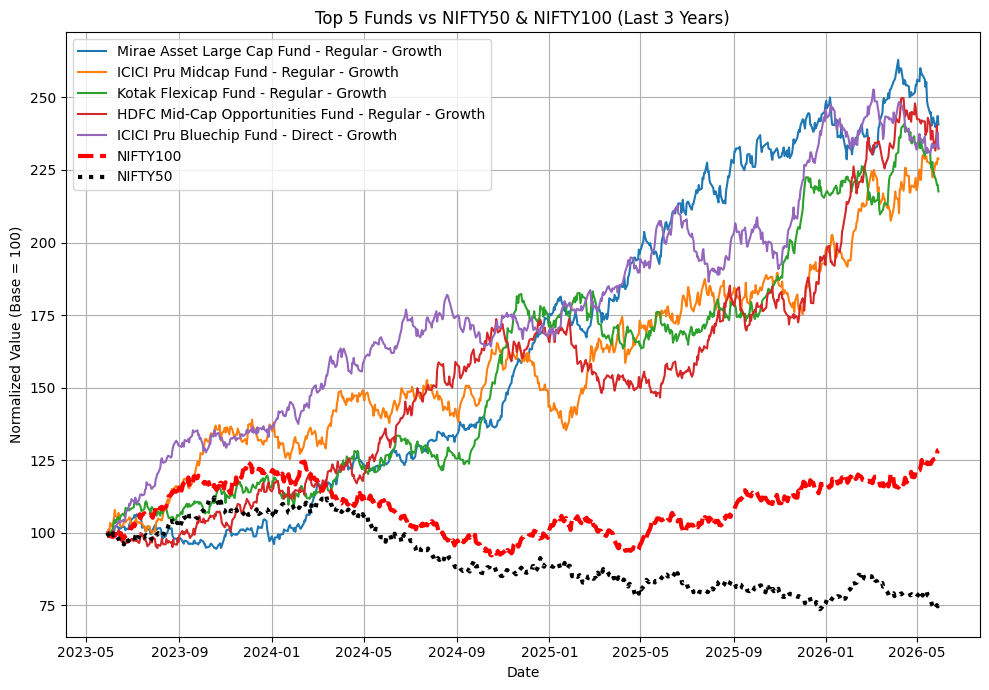

In [42]:
plt.figure(figsize=(10,7))

for code in top5_codes:
    temp = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(temp["date"], temp["Normalized_NAV"], label=temp["scheme_name"].iloc[0])

plt.plot(benchmark_df["date"], benchmark_df["Normalized"], color="red", linewidth=3, linestyle="--", label="NIFTY100")

plt.plot(nifty50_df["date"], nifty50_df["Normalized"], color="black", linewidth=3, linestyle=":", label="NIFTY50")

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png",dpi=300)

plt.show()

### Observation

The top five funds were compared against the NIFTY50 and NIFTY100 benchmarks over the last three years after normalizing all series to a base value of 100. Normalization allows comparison of relative growth despite different starting NAVs and index values. The selected funds generally exhibited stronger growth than the benchmark indices over the observed period, indicating better cumulative performance. Any unexpected benchmark movement reflects the benchmark data available in the dataset used for analysis rather than the normalization methodology.

## Tracking error 

In [47]:
nifty50_df["benchmark_return"] = (nifty50_df["close_value"].pct_change())

tracking_error_list = []

for code in top5_codes:
    fund = nav_df[nav_df["amfi_code"] == code][["date", "scheme_name", "daily_return"]].copy()
    merged = fund.merge(nifty50_df[["date", "benchmark_return"]], on="date", how="inner").dropna()
    tracking_error = ((merged["daily_return"] - merged["benchmark_return"]).std()) * np.sqrt(252)
    tracking_error_list.append({"amfi_code": code,"scheme_name": fund["scheme_name"].iloc[0],"Tracking_Error": tracking_error})

In [49]:
tracking_df = pd.DataFrame(tracking_error_list)
tracking_df.sort_values("Tracking_Error")
print(tracking_df)

   amfi_code                                        scheme_name  \
0     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1     120505           ICICI Pru Midcap Fund - Regular - Growth   
2     120843             Kotak Flexicap Fund - Regular - Growth   
3     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4     120504          ICICI Pru Bluechip Fund - Direct - Growth   

   Tracking_Error  
0        0.193996  
1        0.233124  
2        0.205148  
3        0.229755  
4        0.191376  


### Observation

Tracking Error was calculated as the annualized standard deviation of the difference between the fund's daily returns and the benchmark's daily returns using √252 trading days. The results indicate that ICICI Pru Bluechip Fund exhibited the lowest tracking error, suggesting that its performance closely matched the benchmark. Conversely, ICICI Pru Midcap Fund showed the highest tracking error among the top five funds, indicating greater deviation from benchmark movements and a relatively more active investment strategy.